In [1]:
import numpy as np 
import pandas as pd 
import pickle as pkl 
import matplotlib.pyplot as plt  

with open(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\resources\gen_sim_glove_50.pkl', 'rb') as f: 
    glove_vectors = pkl.load(f)

one_attention_weights = pd.read_csv(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\attention_weights\1.2.3_C1_attention_weights.csv')
two_attention_weights = pd.read_csv(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\attention_weights\2.4.1_C1_attention_weights.csv')
three_attention_weights = pd.read_csv(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\attention_weights\3.1.3_C1_attention_weights.csv')

pickle_file = r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\preprocessed_features\1.2.3_kinect_sep_09.pkl'
with open(pickle_file, 'rb') as f: 
    data = pkl.load(f)

print(data)

{'skel_post':        J0_dist_from_J1  J0_speed  J0_acceleration  J1_speed  J1_acceleration  \
frame                                                                          
91                 NaN       NaN              NaN       NaN              NaN   
92                 NaN       NaN              NaN       NaN              NaN   
93                 NaN       NaN              NaN       NaN              NaN   
94                 NaN       NaN              NaN       NaN              NaN   
95                 NaN       NaN              NaN       NaN              NaN   
...                ...       ...              ...       ...              ...   
14589        -1.579637  2.877439          2.65342  3.202544         0.001404   
14590        -1.420320  2.877439          2.65342  3.202544         0.001404   
14591        -2.162512  2.877439          2.65342  3.202544         0.001404   
14592        -2.162512  2.877439          2.65342  3.202544         0.001404   
14593        -2.162512  2.

In [13]:
frame_1_one = one_attention_weights[one_attention_weights['frame'] == 1]
print(frame_1_one.head())

emb_dim = glove_vectors['apple'].shape[0]  

average = np.zeros(shape=(1,emb_dim))
for _, row in frame_1_one.iterrows(): 
    r = np.zeros(shape=(1,emb_dim)) 
    cur_word = row['object'].split(' ')
    print(cur_word)
    attention_weight = row['attention_weight'] 
    for word in cur_word: 
        word = ''.join([char for char in word if char.isalpha()]) 
        print("this is the word", word)
        r += glove_vectors[word] #adds both words if there are two in a scene  
    r /= len(cur_word) 
    weighted_emb = r * attention_weight 
    print(weighted_emb)
    average += weighted_emb  
print("this is the average",average/len(frame_1_one))
    
        

# def get_emb(df, emb_dim, attention_weights): 
#     average = np.zeros(shape=(1, emb_dim))
#     for _, row in df.iterrows():
#         r = np.zeros(shape=(1, emb_dim))
#         try:
#             r += glove_vectors[row['name']]
#         except Exception as e:
#             # if object not in glove, split into words
#             words = row['name'].split(' ')
#             for w in words:
#                 w = w.replace('(', '').replace(')', '')
#                 r += glove_vectors[w]
#             r /= len(words)
#         # equal contribution from each object
#         average += r * attention_weights[row['name']] #multiply by the attentional weight here
#     return average / len(df) 


   frame         object  attention_weight
0      1      dumbbell0          0.000001
1      1      dumbbell1          0.000001
2      1          step0          0.000001
3      1        helmet0          0.207972
4      1  spray bottle0          0.172406
['dumbbell0']
this is the word dumbbell
[[-9.10099979e-08  2.25459996e-07 -3.46309994e-07 -5.75919993e-07
   3.17370001e-07  4.45340013e-07  1.63469996e-06  3.23800001e-07
   1.87910008e-07  1.51820006e-07 -5.01749998e-07  3.33750013e-07
   8.18610022e-07  1.11920000e-06 -7.21960017e-07 -4.50620001e-07
  -4.36439996e-07  6.44640036e-07  1.49159999e-07 -5.47230012e-07
   2.87460003e-07 -9.33189999e-07 -1.18840003e-07 -9.08570002e-08
  -3.35550014e-07 -1.49000000e-08  2.45480004e-07  1.14470006e-06
  -1.06330001e-07 -1.07570006e-06 -2.89099995e-07  7.99049983e-07
  -2.33710009e-07  1.28610005e-06  4.38230006e-08  6.17420025e-07
   5.48240012e-07 -1.67550000e-08  1.98379996e-07 -2.85090003e-07
   3.48899994e-07  1.00130000e-07 -6.33520015e-0

: 

Canonical Correlation Analysis 


In [17]:
import cv2 
video_path = r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\data\small_videos\2.4.1_C1_trim.mp4"
cap = cv2.VideoCapture(video_path) 

fps = cap.get(cv2.CAP_PROP_FPS) 
print("this is the fps of the video", fps)

this is the fps of the video 59.94005994005994


In [2]:
attention_embs = pd.read_csv(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\scene_embs\2.4.1_C1_scene_vectors.csv')
hand_embs = pd.read_csv(r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\scene_embs\2.4.1_kinect_sep_09_nearest_objects_emb.csv")
attention_embs.head()



,frame,attention_1,attention_2,attention_3,attention_4,attention_5,attention_6,attention_7,attention_8,attention_9,...,attention_41,attention_42,attention_43,attention_44,attention_45,attention_46,attention_47,attention_48,attention_49,attention_50
0,1,-0.005352,-0.002383,-0.005312,-0.002397,-0.005830,0.006337,0.003350,-0.002179,0.005894,...,0.006176,-0.004429,-0.002771,0.010208,0.005344,-0.000203,0.009849,0.001540,-0.000114,0.000576
1,2,-0.003093,-0.001655,-0.004537,-0.001065,-0.005465,0.005291,0.002009,-0.001629,0.003608,...,0.003262,-0.003152,-0.001995,0.006082,0.004169,0.000379,0.005248,0.001457,-0.000637,0.001626
2,3,-0.003374,-0.001321,-0.002091,-0.001854,-0.001973,0.002823,0.002115,-0.001139,0.003604,...,0.004174,-0.002168,-0.001411,0.006240,0.002318,-0.000391,0.006377,0.000698,0.000414,-0.000764
3,4,-0.002618,-0.001430,-0.003742,-0.000984,-0.004569,0.004566,0.001754,-0.001428,0.003098,...,0.002799,-0.002534,-0.001664,0.005107,0.003352,0.000427,0.004299,0.001384,-0.000506,0.001278
4,5,-0.008017,-0.003575,-0.006709,-0.000456,-0.003444,0.005533,0.001073,-0.000682,0.002902,...,0.006989,0.000194,-0.004839,0.008462,0.005768,0.000761,0.003893,-0.003125,0.002180,-0.003159


In [5]:
import pandas as pd 

attention_1_embs = pd.read_csv(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\scene_embs\1.2.3_C1_scene_vectors.csv')
hand_1_embs = pd.read_csv(r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\scene_embs\1.2.3_kinect_sep_09_nearest_objects_emb.csv")
print(hand_1_embs.shape)
print(hand_1_embs.dropna(how='any').shape)
aligned_1_df = pd.read_csv(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\scene_embs\1.2.3_aligned_hand_attention.csv') 
print(aligned_1_df.shape)


(14625, 51)
(14479, 51)
(14479, 104)


In [15]:

def align_and_save_embeddings(attention_csv, hand_csv, name, output_dir):
    '''Function that aligns the attention and hand embeddings (via nearest neighbor) and saves them to a csv'''
    import os
    import pandas as pd
    import numpy as np 

    
    attention_embs = pd.read_csv(attention_csv)
    hand_embs = pd.read_csv(hand_csv)

    
    clean_attention_embs = attention_embs.fillna(1e-6) #fill NA with lowest value of attention weights 1e-6
    # clean_hand_embs = hand_embs.dropna(how='any')

    #calculate timestamps for both attention and hand embeddings 
    hand_embs['timestamps_hand'] = hand_embs['frame'] / 25
    clean_attention_embs['timestamps_attention'] = clean_attention_embs['frame'] / 59.94

  
    tolerance = 0.05 #tolerance of 0.05 seconds 
    aligned_df = pd.merge_asof(
        hand_embs,
        clean_attention_embs,
        left_on='timestamps_hand',
        right_on='timestamps_attention',
        direction='nearest',
        tolerance=tolerance
    )
    print("previous data shape", aligned_df.shape)
    col_objhand = [col for col in aligned_df.columns if col.startswith("objhand_")]
    col_attention = [col for col in aligned_df.columns if col.startswith("attention_")]
    mask = aligned_df[col_objhand].isna().any(axis=1) #if there are any nan values in row with columns of col_objhand 
    aligned_df.loc[mask, col_attention] = np.nan #replace the attention values with nan (for resampling purposes)
    print("after removing nan", aligned_df.shape)


    output_path = os.path.join(output_dir, f'{name}_aligned_hand_attention.csv')
    aligned_df.to_csv(output_path, index=False)
    return aligned_df


aligned_df_1 = align_and_save_embeddings(
    attention_csv=r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\scene_embs\6.3.9_C1_scene_vectors.csv',
    hand_csv=r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\scene_embs\6.3.9_kinect_sep_09_nearest_objects_emb.csv',
    name='6.3.9',
    output_dir=r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\scene_embs'
)

previous data shape (16844, 104)
after removing nan (16844, 104)


In [12]:
print(aligned_df_1)

       frame_x  objhand_0  objhand_1  objhand_2  objhand_3  objhand_4  \
0            0        NaN        NaN        NaN        NaN        NaN   
1            1        NaN        NaN        NaN        NaN        NaN   
2            2        NaN        NaN        NaN        NaN        NaN   
3            3        NaN        NaN        NaN        NaN        NaN   
4            4        NaN        NaN        NaN        NaN        NaN   
...        ...        ...        ...        ...        ...        ...   
14620    14620        NaN        NaN        NaN        NaN        NaN   
14621    14621        NaN        NaN        NaN        NaN        NaN   
14622    14622        NaN        NaN        NaN        NaN        NaN   
14623    14623        NaN        NaN        NaN        NaN        NaN   
14624    14624        NaN        NaN        NaN        NaN        NaN   

       objhand_5  objhand_6  objhand_7  objhand_8  ...  attention_42  \
0            NaN        NaN        NaN        NaN  

In [11]:
align_and_save_embeddings(
    attention_csv=r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\scene_embs\6.3.9_C1_scene_vectors.csv',
    hand_csv=r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\scene_embs\6.3.9_kinect_sep_09_nearest_objects_emb.csv',
    name='6.3.9',
    output_dir=r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\scene_embs'
)

c:\Users\super\anaconda3\envs\sem-viz-jupyter\lib\site-packages\ipykernel_launcher.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [3]:
hand_embs.head()
cleaned_hand_embs = hand_embs.dropna(how='any')

fps_hand = 25 
hand_frames = cleaned_hand_embs['frame'].values 
hand_time_stamps = hand_frames/fps_hand 
print(hand_time_stamps)  

cleaned_hand_embs['timestamps_hand'] = cleaned_hand_embs['frame']/25 
cleaned_hand_embs['timestamps_hand']



[  6.6    6.64   6.68 ... 629.44 629.48 629.52]


c:\Users\super\anaconda3\envs\sem-viz-jupyter\lib\site-packages\ipykernel_launcher.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if __name__ == "__main__":


165        6.60
166        6.64
167        6.68
168        6.72
169        6.76
          ...  
15734    629.36
15735    629.40
15736    629.44
15737    629.48
15738    629.52
Name: timestamps_hand, Length: 15574, dtype: float64

In [18]:
attention_embs['timestamps_attention'] = attention_embs['frame']/59.94 
attention_embs['timestamps_attention'].max()


630.0133466800133

In [19]:
tolerance = 0.05
aligned_df = pd.merge_asof(cleaned_hand_embs, attention_embs, left_on='timestamps_hand',
                           right_on = 'timestamps_attention',
                           direction='nearest', tolerance=tolerance)
pd.set_option('display.max_columns',None)
aligned_df.tail(3)
# print(aligned_df['timestamps_hand'])
# print(aligned_df['timestamps_attention'])


,frame_x,objhand_0,objhand_1,objhand_2,objhand_3,objhand_4,objhand_5,objhand_6,objhand_7,objhand_8,objhand_9,objhand_10,objhand_11,objhand_12,objhand_13,objhand_14,objhand_15,objhand_16,objhand_17,objhand_18,objhand_19,objhand_20,objhand_21,objhand_22,objhand_23,objhand_24,objhand_25,objhand_26,objhand_27,objhand_28,objhand_29,objhand_30,objhand_31,objhand_32,objhand_33,objhand_34,objhand_35,objhand_36,objhand_37,objhand_38,objhand_39,objhand_40,objhand_41,objhand_42,objhand_43,objhand_44,objhand_45,objhand_46,objhand_47,objhand_48,objhand_49,timestamps_hand,frame_y,attention_1,attention_2,attention_3,attention_4,attention_5,attention_6,attention_7,attention_8,attention_9,attention_10,attention_11,attention_12,attention_13,attention_14,attention_15,attention_16,attention_17,attention_18,attention_19,attention_20,attention_21,attention_22,attention_23,attention_24,attention_25,attention_26,attention_27,attention_28,attention_29,attention_30,attention_31,attention_32,attention_33,attention_34,attention_35,attention_36,attention_37,attention_38,attention_39,attention_40,attention_41,attention_42,attention_43,attention_44,attention_45,attention_46,attention_47,attention_48,attention_49,attention_50,timestamps_attention
15571,15736,-0.401196,-0.493403,-0.305957,-0.029888,-0.613677,0.499616,0.408470,0.056337,0.536923,0.150312,-0.242431,0.589261,0.387938,0.430901,-0.087843,0.689417,-0.486506,0.500141,0.080693,-1.010806,0.646187,0.211848,0.237066,-0.416715,-0.091522,-0.429282,-0.165139,1.357920,1.016646,-0.422954,-0.024179,0.296409,-0.154323,0.833649,-0.436953,0.796558,0.135611,0.341806,1.122055,-0.177964,0.740448,0.354034,-0.391555,1.161984,-0.114458,0.470071,0.194046,-0.162468,0.291760,-0.569448,629.44,37729,0.464184,-0.476420,-0.155636,0.475046,-1.307117,0.240851,0.631413,0.414577,0.578353,-0.271902,-0.367362,1.260938,0.388009,1.131366,-0.041562,0.790811,-0.954666,1.369702,0.838077,-1.471055,0.612645,-0.054010,-0.250693,-0.113238,0.522312,-0.530535,-0.330594,1.438814,0.928071,-0.351375,0.041047,-0.050930,-0.208431,1.400109,-0.457983,1.239121,-0.024926,0.512887,2.109157,-0.263555,0.667416,0.303431,-0.448499,1.982658,-0.293808,0.458228,0.885137,-0.767807,0.253522,-0.569247,629.446113
15572,15737,-0.403178,-0.493619,-0.306521,-0.031898,-0.613060,0.502000,0.408724,0.054602,0.537865,0.152225,-0.241928,0.588325,0.388618,0.428569,-0.089067,0.689492,-0.485888,0.498711,0.079494,-1.009077,0.646789,0.212470,0.238915,-0.417122,-0.093205,-0.428710,-0.166346,1.357508,1.016491,-0.424481,-0.025644,0.297129,-0.153406,0.831953,-0.435868,0.795639,0.136291,0.340663,1.120212,-0.177569,0.741096,0.353578,-0.391400,1.160843,-0.113948,0.470348,0.193517,-0.159318,0.291461,-0.568987,629.48,37731,0.491587,-0.464864,-0.122161,0.487281,-1.277904,0.207135,0.622432,0.428360,0.553737,-0.248077,-0.372037,1.246574,0.362369,1.155847,-0.025448,0.776342,-0.916152,1.361754,0.792225,-1.481210,0.609857,-0.055984,-0.269878,-0.112414,0.515112,-0.536028,-0.282347,1.443004,0.928307,-0.285193,0.034392,-0.055059,-0.215118,1.371816,-0.440292,1.208682,-0.040417,0.499566,2.060762,-0.255404,0.644694,0.330031,-0.435255,1.948951,-0.332325,0.464003,0.844508,-0.780537,0.258999,-0.580683,629.479479
15573,15738,-0.404561,-0.493776,-0.306934,-0.033055,-0.612511,0.503219,0.408746,0.053654,0.538338,0.153125,-0.241651,0.587636,0.388981,0.427197,-0.089645,0.689541,-0.485532,0.497686,0.078781,-1.008130,0.647094,0.212868,0.240027,-0.417451,-0.094228,-0.428428,-0.166966,1.357348,1.016507,-0.425411,-0.026235,0.297631,-0.152980,0.831076,-0.435482,0.795195,0.136694,0.340172,1.119147,-0.177414,0.741515,0.353340,-0.391358,1.160081,-0.113511,0.470434,0.193111,-0.157663,0.291357,-0.568809,629.52,37733,0.491658,-0.454796,-0.112679,0.486749,-1.255065,0.195627,0.611920,0.427598,0.537867,-0.235383,-0.368976,1.226971,0.350332,1.146887,-0.018922,0.761970,-0.893044,1.342677,0.766187,-1.465084,0.601104,-0.054319,-0.274643,-0.112594,0.508403,-0.530733,-0.258636,1.425067,0.917820,-0.258038,0.031090,-0.054664,-0.

In [23]:
#save to csv 
import os

output_dir = r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\scene_embs"
output_path = os.path.join(output_dir, '2.4.1_aligned_hand_attention.csv')
aligned_df.to_csv(output_path, index=False)


This is X:
[[-0.67772231 -0.16568045 -0.23500946 ... -0.44854206  0.37059742
  -0.66630894]
 [-0.6772233  -0.16523668 -0.23549129 ... -0.44826272  0.37031327
  -0.66571502]
 [-0.67663492 -0.16471662 -0.2360101  ... -0.4479265   0.36998515
  -0.66503689]
 ...
 [-0.40119586 -0.49340331 -0.30595689 ... -0.1624679   0.29176023
  -0.56944819]
 [-0.4031779  -0.49361878 -0.30652103 ... -0.1593179   0.29146105
  -0.56898702]
 [-0.40456116 -0.49377571 -0.3069338  ... -0.15766321  0.29135668
  -0.56880938]]
This is Y
[[-6.79123574e-07 -3.08041430e-07 -1.45157133e-07 ... -1.85835423e-07
   1.95038288e-07 -4.20402657e-07]
 [-6.79123574e-07 -3.08041430e-07 -1.45157133e-07 ... -1.85835423e-07
   1.95038288e-07 -4.20402657e-07]
 [-6.79123574e-07 -3.08041430e-07 -1.45157132e-07 ... -1.85835423e-07
   1.95038289e-07 -4.20402658e-07]
 ...
 [ 4.64183774e-01 -4.76420401e-01 -1.55635522e-01 ... -7.67807360e-01
   2.53522244e-01 -5.69246535e-01]
 [ 4.91587338e-01 -4.64864005e-01 -1.22160579e-01 ... -7.80537

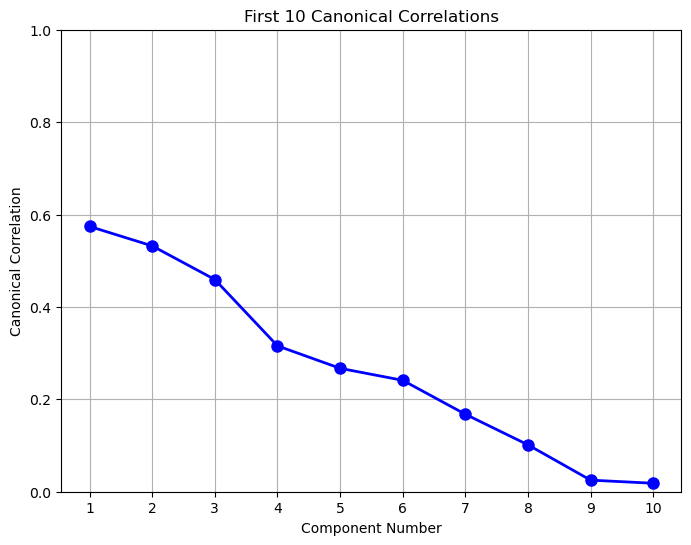

In [4]:
import pandas as pd
import numpy as np
from sklearn.cross_decomposition import CCA
import matplotlib.pyplot as plt

def canonical_analysis(file_path):
    df = pd.read_csv(file_path)
  
    objhand_columns = [col for col in df.columns if col.startswith("objhand_")]
    attention_columns = [col for col in df.columns if col.startswith("attention_")]
   
    X = df[objhand_columns].values      # Shape: (n_frames, 50)
    Y = df[attention_columns].values    # Shape: (n_frames, 50)
  
   
    mask = np.all(np.isfinite(X), axis=1) & np.all(np.isfinite(Y), axis=1) #this just makes sure that there are no infinite values
    X = X[mask]
    Y = Y[mask]

    n_components = min(X.shape[1], Y.shape[1]) #or just 50, since neither have more than 50 

    #standardize
#     scaler_X = StandardScaler()
#     scaler_Y = StandardScaler()
#     X_scaled = scaler_X.fit_transform(X)
#     Y_scaled = scaler_Y.fit_transform(Y)
    cca = CCA(n_components=n_components, max_iter=1000)
    cca.fit(X, Y)

    X_c, Y_c = cca.transform(X, Y) #calculates the canonical variates 
    print("This is X c", X_c)
    print("this is Yc", Y_c)

   
    canonical_corrs = [np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1] for i in range(n_components)]
    print("Canonical correlations:")
    for i, corr in enumerate(canonical_corrs):
        print(f"Component {i+1}: {corr:.4f}")

    # -------------------------
    # Compute the Redundancy Index
    # -------------------------
    # For set X (i.e., how much variance in X is explained by the canonical variates from Y)
    redundancy_X = []
    for i in range(n_components):
        structure_coeffs_X = [
            np.corrcoef(X[:, j], X_c[:, i])[0, 1] for j in range(X.shape[1])
        ] #how much the canonical variable is explaining X normally 
        avg_sq_loading = np.mean(np.square(structure_coeffs_X))
        # Redundancy index for this canonical function is:
        red_index = avg_sq_loading * (canonical_corrs[i] ** 2) #square of correlation coefficient is coefficient of determination
        redundancy_X.append(red_index)

    # For set Y (i.e., how much variance in Y is explained by the canonical variates from X)
    redundancy_Y = []
    for i in range(n_components):
        structure_coeffs_Y = [
            np.corrcoef(Y[:, j], Y_c[:, i])[0, 1] for j in range(Y.shape[1])
        ]
        avg_sq_loading = np.mean(np.square(structure_coeffs_Y))
        red_index = avg_sq_loading * (canonical_corrs[i] ** 2)
        redundancy_Y.append(red_index)

    print("\nRedundancy Indices:")
    print("  For X (hand vector) (variance in X explained by canonical variates of Y (attention vector)):")
    sum_redundancy_X = np.sum(redundancy_X) 
    print(sum_redundancy_X)
    print("  For Y (attention vector) (variance in Y explained by canonical variates of X (hand vector)):")
    sum_redundancy_Y = np.sum(redundancy_Y)
    print("Y explained by variates of X:", sum_redundancy_Y)


    plt.figure(figsize=(8, 6))
    components = range(1, 11)  # First 10 components
    correlations = canonical_corrs[:10]
    plt.plot(components, correlations, 'bo-', linewidth=2, markersize=8)
    plt.xlabel("Component Number")
    plt.ylabel("Canonical Correlation")
    plt.title("First 10 Canonical Correlations")
    plt.grid(True)
    plt.xticks(components)
    plt.ylim(0, 1)  # Correlations are between 0 and 1
    plt.show()

file_path_2 = r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\scene_embs\2.4.1_aligned_hand_attention.csv"
canonical_analysis(file_path_2)

This is X c [[ 6.98794900e+00 -3.63007519e+00  4.39397696e+00 ... -2.77794260e-12
  -9.37916411e-13  8.46966941e-12]
 [ 6.98193389e+00 -3.62848155e+00  4.39191829e+00 ... -2.78975882e-12
  -9.46798195e-13  8.49098569e-12]
 [ 6.97680739e+00 -3.62695604e+00  4.39060028e+00 ... -2.80803601e-12
  -9.50350909e-13  8.49098569e-12]
 ...
 [ 2.62160651e+00  3.17694521e-01 -1.74716273e+00 ... -1.17239551e-13
  -1.95399252e-13  9.94759830e-14]
 [ 2.58817215e+00  3.19888467e-01 -1.77472705e+00 ... -8.17124146e-14
  -1.86517468e-13  4.97379915e-14]
 [ 2.55912386e+00  3.20118200e-01 -1.79893260e+00 ... -7.81597009e-14
  -1.84741111e-13 -2.84217094e-14]]
this is Yc [[-4.51832270e-01 -2.08943860e-01 -9.86935365e-01 ...  1.68383671e-13
  -3.27723959e-14  2.48689958e-14]
 [-5.08028133e-01 -5.62036312e-02 -1.10814709e+00 ...  7.16182694e-14
   5.37070388e-15  4.32431868e-14]
 [ 2.27808155e-01 -8.86775846e-03 -1.03288280e+00 ... -8.41606762e-14
   3.67032793e-14 -1.01169073e-14]
 ...
 [ 2.12099975e+00  5.

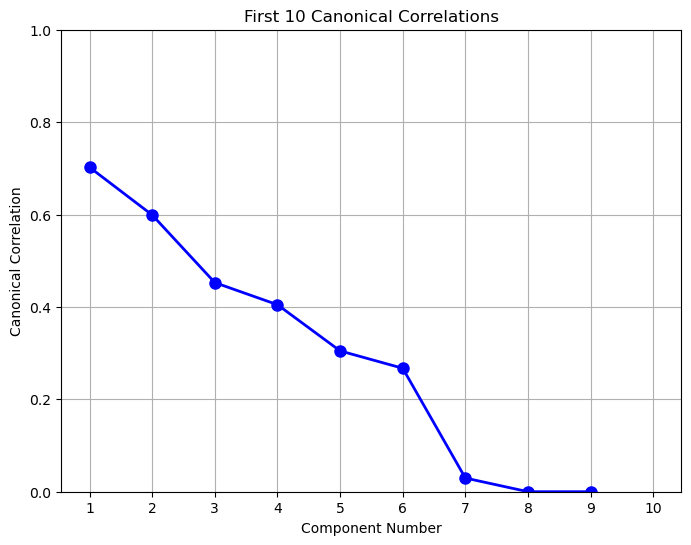

In [3]:
file_path_1 = r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\scene_embs\1.2.3_aligned_hand_attention.csv"
canonical_analysis(file_path_1)

In [6]:
import os 

def fill_attention_weights(file_path):
    '''function that fills in the nan values in attention weights with 1e-6'''
    df = pd.read_csv(file_path)
    df_filled = df.fillna(1e-6)
    
    # Get directory and filename, then create a new name with '_filled' appended
    directory, filename = os.path.split(file_path)
    basename, ext = os.path.splitext(filename)
    new_filename = f"{basename}_filled{ext}"
    new_file_path = os.path.join(directory, new_filename)
    
    df_filled.to_csv(new_file_path, index=False)
    print(f"Saved filled CSV file to: {new_file_path}")
    return new_file_path

file_path_3 = r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\attention_weights\3.1.3_C1_attention_weights.csv"
fill_attention_weights(file_path_3)


Saved filled CSV file to: C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\attention_weights\3.1.3_C1_attention_weights_filled.csv


'C:\\Users\\super\\OneDrive\\Desktop\\Github repos\\extended-event-modeling\\output\\attention_weights\\3.1.3_C1_attention_weights_filled.csv'

In [9]:
file_path_1 = r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\attention_weights\1.2.3_C1_attention_weights.csv" 
file_path_4 = r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\attention_weights\6.3.9_C1_attention_weights.csv"

fill_attention_weights(file_path_1)
fill_attention_weights(file_path_4)

Saved filled CSV file to: C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\attention_weights\1.2.3_C1_attention_weights_filled.csv
Saved filled CSV file to: C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\attention_weights\6.3.9_C1_attention_weights_filled.csv


'C:\\Users\\super\\OneDrive\\Desktop\\Github repos\\extended-event-modeling\\output\\attention_weights\\6.3.9_C1_attention_weights_filled.csv'

This is X c [[-4.75914680e-01 -1.10487516e-01  8.86585082e-01 ...  1.54675646e-14
   8.82745212e-15  3.37230244e-15]
 [-4.77730671e-01 -1.09714107e-01  8.85892330e-01 ...  1.39773079e-14
   1.07402626e-14  2.12330153e-15]
 [-4.79660382e-01 -1.08882310e-01  8.85157773e-01 ...  1.46402636e-14
   1.08983731e-14  1.90125693e-15]
 ...
 [-2.82398055e+00  3.43762581e-01 -5.90298944e-01 ...  9.54791801e-15
  -3.38661391e-15  3.24185123e-14]
 [-2.82460446e+00  3.43918880e-01 -5.90305834e-01 ...  1.02140518e-14
  -2.10367748e-15  3.21964677e-14]
 [-2.82620399e+00  3.44317036e-01 -5.90431262e-01 ...  1.02140518e-14
  -1.29442897e-15  3.35287353e-14]]
this is Yc [[ 3.06254632e-02 -2.82015840e-01  1.50761896e-01 ...  1.25689064e-13
  -1.64174230e-13  2.66453526e-15]
 [ 2.60449146e-02 -2.35359969e-01  2.33849851e-01 ... -9.56001565e-14
  -1.01502140e-13 -1.18016708e-13]
 [ 4.56890311e-03 -2.12577117e-01  2.93736872e-01 ... -1.98160794e-13
  -1.58761893e-13 -2.72309952e-13]
 ...
 [-1.92814768e+00  8.

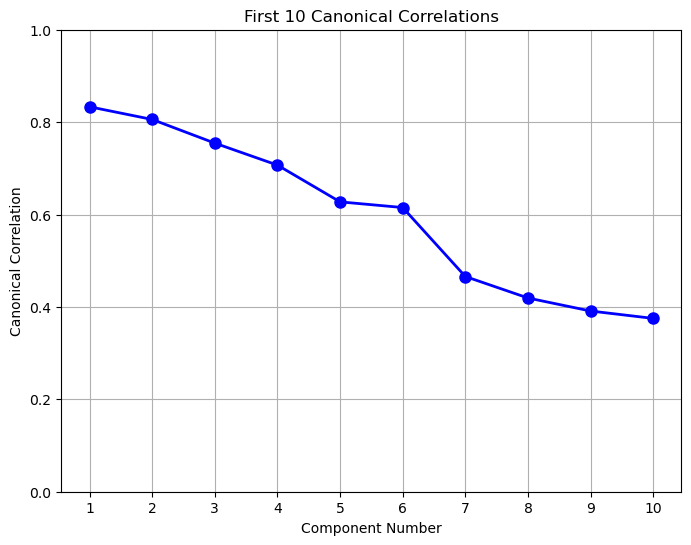

In [12]:
file_path_new_3 = r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\scene_embs\3.1.3_aligned_hand_attention.csv"
canonical_analysis(file_path_new_3)
#for 3.1.3

This is X c [[ 3.70455315e-01  1.39519645e+00 -9.73281370e-01 ... -2.65459201e-14
  -1.47659662e-14 -2.55351296e-14]
 [ 3.70530322e-01  1.39229457e+00 -9.74089189e-01 ... -2.76852491e-14
  -1.72362125e-14 -2.53130850e-14]
 [ 3.70690257e-01  1.38699508e+00 -9.75559327e-01 ... -2.77858037e-14
  -1.79578574e-14 -2.19824159e-14]
 ...
 [ 8.86763565e-02  7.99746638e-01 -9.14175652e-01 ... -1.92431039e-14
  -6.18671780e-14  6.29496455e-14]
 [ 8.77914420e-02  7.98971854e-01 -9.13903227e-01 ... -1.91934980e-14
  -6.22280005e-14  6.63358257e-14]
 [ 9.36322205e-02  6.79341224e-01 -8.36816959e-01 ... -5.14033260e-14
  -2.74780199e-15 -2.65343303e-14]]
this is Yc [[-1.17392335e-02  2.36815148e-01  3.95125490e-02 ... -3.52509727e-12
  -5.21804822e-14 -1.08209969e-12]
 [-1.17758798e-02  2.37864892e-01  3.98193426e-02 ... -3.56293227e-12
  -5.26245714e-14 -1.09550910e-12]
 [-9.07655892e-03  2.38413757e-01  3.61218047e-02 ... -3.49013902e-12
  -4.39648318e-14 -1.07959822e-12]
 ...
 [ 1.56901057e-02  5.

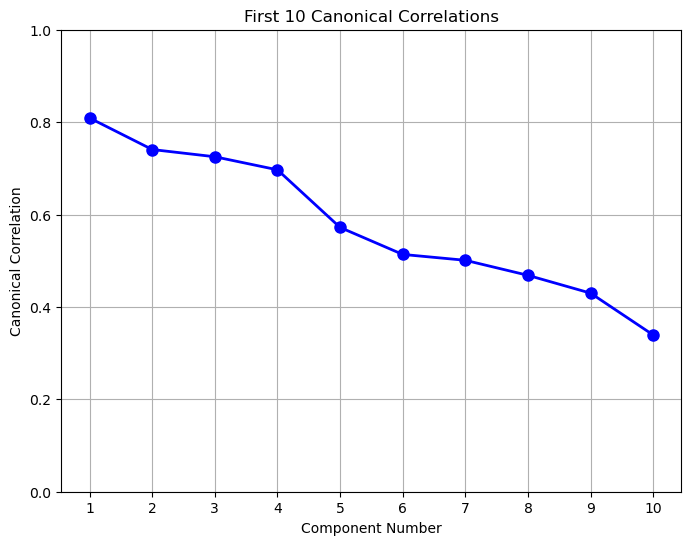

In [13]:
file_path_new_4 = r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\scene_embs\6.3.9_aligned_hand_attention.csv"
canonical_analysis(file_path_new_4)
#for 6.3.9